<a href="https://colab.research.google.com/github/RishikaBhawsingka/NLP-ML-project/blob/main/5_Naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

BASE_DIR = "/content/drive/MyDrive/HumanBehaviourSimulator"

DATASET_DIR = os.path.join(BASE_DIR, "datasets")
CLEAN_DIR = os.path.join(BASE_DIR, "cleaned_data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
PLOT_DIR = os.path.join(BASE_DIR, "plots", "Naive_Bayes")
REPORT_DIR = os.path.join(BASE_DIR, "reports")

os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("✅ Project Loaded Successfully")

Mounted at /content/drive
✅ Project Loaded Successfully


In [ ]:
#load clean datset
train = pd.read_csv(
    os.path.join(CLEAN_DIR, "train_clean.csv"),
    keep_default_na=False
)

validation = pd.read_csv(
    os.path.join(CLEAN_DIR, "validation_clean.csv"),
    keep_default_na=False
)

test = pd.read_csv(
    os.path.join(CLEAN_DIR, "test_clean.csv"),
    keep_default_na=False
)

print(train.shape)
print(validation.shape)
print(test.shape)

(43410, 5)
(5426, 5)
(5427, 5)


In [ ]:
#same tf-idf setting as it was in logistic_reg
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(train["clean_text"])
X_validation = tfidf.transform(validation["clean_text"])
X_test = tfidf.transform(test["clean_text"])

y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]

print(X_train.shape)
print(X_validation.shape)
print(X_test.shape)

(43410, 5000)
(5426, 5000)
(5427, 5000)


In [ ]:
joblib.dump(
    tfidf,
    os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl")
)

print("✅ TF-IDF Saved")

✅ TF-IDF Saved


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB(alpha=0.1)

nb_model.fit(X_train, y_train)

print("✅ Naive Bayes Model Trained")

✅ Naive Bayes Model Trained


In [ ]:
# Predict on validation set
y_validation_pred = nb_model.predict(X_validation)

print("✅ Validation Prediction Completed")

✅ Validation Prediction Completed


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

validation_accuracy = accuracy_score(y_validation, y_validation_pred)

validation_precision = precision_score(
    y_validation,
    y_validation_pred,
    average="weighted",
    zero_division=0
)

validation_recall = recall_score(
    y_validation,
    y_validation_pred,
    average="weighted",
    zero_division=0
)

validation_f1 = f1_score(
    y_validation,
    y_validation_pred,
    average="weighted",
    zero_division=0
)

print("="*50)
print("📊 Naive Bayes - Validation Results")
print("="*50)

print(f"Accuracy : {validation_accuracy:.4f}")
print(f"Precision: {validation_precision:.4f}")
print(f"Recall   : {validation_recall:.4f}")
print(f"F1 Score : {validation_f1:.4f}")

📊 Naive Bayes - Validation Results
Accuracy : 0.4043
Precision: 0.4545
Recall   : 0.4043
F1 Score : 0.3186


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_validation,
        y_validation_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.55      0.51      0.53       488
           1       0.68      0.33      0.44       297
           2       0.45      0.12      0.19       192
           3       0.25      0.05      0.08       247
           4       0.37      0.06      0.11       355
           5       0.27      0.07      0.11       138
           6       0.67      0.04      0.08       136
           7       0.36      0.04      0.07       205
           8       0.86      0.09      0.17        64
           9       0.50      0.02      0.04       129
          10       0.15      0.01      0.02       246
          11       0.73      0.15      0.25        74
          12       0.75      0.11      0.19        28
          13       0.60      0.08      0.14        78
          14       0.65      0.15      0.24        74
          15       0.75      0.52      0.61       297
          16       0.00      0.00      0.00        10
          17       0.37    

In [ ]:
from sklearn.metrics import confusion_matrix

cm_validation = confusion_matrix(
    y_validation,
    y_validation_pred
)

print(cm_validation.shape)

(28, 28)


In [ ]:
joblib.dump(
    nb_model,
    os.path.join(MODEL_DIR, "naive_bayes.pkl")
)

print("✅ Naive Bayes Model Saved")

✅ Naive Bayes Model Saved


In [ ]:
# Predict on test dataset
y_test_pred = nb_model.predict(X_test)

print("✅ Test Prediction Completed")

✅ Test Prediction Completed


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

print("="*55)
print("📊 Naive Bayes - Test Results")
print("="*55)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

📊 Naive Bayes - Test Results
Accuracy : 0.4070
Precision: 0.4592
Recall   : 0.4070
F1 Score : 0.3203


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.52      0.47      0.50       504
           1       0.69      0.30      0.42       252
           2       0.51      0.10      0.17       197
           3       0.33      0.07      0.12       286
           4       0.33      0.07      0.11       318
           5       0.40      0.11      0.17       114
           6       0.42      0.04      0.07       139
           7       0.37      0.04      0.08       233
           8       0.67      0.03      0.05        74
           9       0.62      0.04      0.07       127
          10       0.17      0.01      0.02       220
          11       0.69      0.13      0.22        84
          12       0.00      0.00      0.00        30
          13       0.24      0.05      0.08        84
          14       1.00      0.11      0.20        74
          15       0.76      0.55      0.64       288
          16       0.00      0.00      0.00         6
          17       0.45    

In [ ]:
import joblib

joblib.dump(
    nb_model,
    os.path.join(MODEL_DIR, "naive_bayes_alpha_0_1.pkl")
)

print("✅ Best Naive Bayes model saved.")

✅ Best Naive Bayes model saved.


In [ ]:
!pip install python-docx
from docx import Document
from docx.shared import Pt
import os

# ================================
# Create Report
# ================================

doc = Document()

# Title
title = doc.add_heading("Experiment 02: Naive Bayes Report", level=1)
title.runs[0].font.size = Pt(20)

doc.add_paragraph(
    "Model: Multinomial Naive Bayes\n"
    "Dataset: GoEmotions\n"
    "Feature Engineering: TF-IDF (5000 Features)\n"
    "Hyperparameter Tuned: Alpha"
)

# --------------------------------
# Hyperparameter Tuning
# --------------------------------

doc.add_heading("1. Hyperparameter Tuning", level=2)

table = doc.add_table(rows=1, cols=5)
table.style = "Table Grid"

hdr = table.rows[0].cells
hdr[0].text = "Alpha"
hdr[1].text = "Accuracy"
hdr[2].text = "Precision"
hdr[3].text = "Recall"
hdr[4].text = "F1 Score"

experiments = [
    ["0.1", "0.4043", "0.4545", "0.4043", "0.3186"],
    ["0.5", "0.3935", "0.5264", "0.3935", "0.2891"],
    ["1.0", "0.3808", "0.5279", "0.3808", "0.2670"],
    ["2.0", "0.3625", "0.4602", "0.3625", "0.2412"],
]

for exp in experiments:
    row = table.add_row().cells
    for i in range(5):
        row[i].text = exp[i]

# --------------------------------
# Best Model
# --------------------------------

doc.add_heading("2. Best Hyperparameter", level=2)

doc.add_paragraph(
    "Best Alpha: 0.1\n\n"
    "Reason:\n"
    "- Highest Validation Accuracy\n"
    "- Highest Recall\n"
    "- Highest F1 Score"
)

# --------------------------------
# Validation Results
# --------------------------------

doc.add_heading("3. Validation Results", level=2)

doc.add_paragraph(
    "Accuracy : 0.4043\n"
    "Precision: 0.4545\n"
    "Recall   : 0.4043\n"
    "F1 Score : 0.3186"
)

# --------------------------------
# Test Results
# --------------------------------

doc.add_heading("4. Test Results", level=2)

doc.add_paragraph(
    "Accuracy : 0.4070\n"
    "Precision: 0.4592\n"
    "Recall   : 0.4070\n"
    "F1 Score : 0.3203"
)

# --------------------------------
# Observations
# --------------------------------

doc.add_heading("5. Observations", level=2)

doc.add_paragraph(
    "• Four alpha values (0.1, 0.5, 1.0, and 2.0) were evaluated.\n"
    "• Alpha = 0.1 achieved the best validation performance.\n"
    "• Increasing alpha reduced Accuracy, Recall and F1-score.\n"
    "• The model generalized well because validation and test scores were very similar.\n"
    "• Compared to Logistic Regression, Naive Bayes produced lower overall performance on the GoEmotions dataset."
)

# --------------------------------
# Comparison
# --------------------------------

doc.add_heading("6. Model Comparison", level=2)

table2 = doc.add_table(rows=1, cols=3)
table2.style = "Table Grid"

hdr = table2.rows[0].cells
hdr[0].text = "Model"
hdr[1].text = "Accuracy"
hdr[2].text = "F1 Score"

row = table2.add_row().cells
row[0].text = "Logistic Regression"
row[1].text = "0.5126"
row[2].text = "0.4562"

row = table2.add_row().cells
row[0].text = "Naive Bayes"
row[1].text = "0.4070"
row[2].text = "0.3203"

# --------------------------------
# Conclusion
# --------------------------------

doc.add_heading("7. Conclusion", level=2)

doc.add_paragraph(
    "The Multinomial Naive Bayes classifier was trained using TF-IDF features extracted "
    "from the GoEmotions dataset. Hyperparameter tuning showed that alpha = 0.1 provided "
    "the best validation performance. The final model achieved a test accuracy of 40.70% "
    "with an F1-score of 0.3203. Although Naive Bayes performed efficiently and generalized "
    "well, Logistic Regression remained the better-performing classical machine learning "
    "model for this emotion classification task."
)

# --------------------------------
# Save Report
# --------------------------------

report_path = os.path.join(
    REPORT_DIR,
    "Experiment_02_Naive_Bayes_Report.docx"
)

doc.save(report_path)

print("✅ Report Generated Successfully!")
print(report_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.0 MB/s eta 0:00:00
✅ Report Generated Successfully!
/content/drive/MyDrive/HumanBehaviourSimulator/reports/Experiment_02_Naive_Bayes_Report.docx


In [ ]:
#visualisations
import os

BASE_DIR = "/content/drive/MyDrive/HumanBehaviourSimulator"

NB_PLOTS_DIR = os.path.join(
    BASE_DIR,
    "plots",
    "Naive_Bayes"
)

os.makedirs(NB_PLOTS_DIR, exist_ok=True)

print("Saving plots to:")
print(NB_PLOTS_DIR)

Saving plots to:
/content/drive/MyDrive/HumanBehaviourSimulator/plots/Naive_Bayes


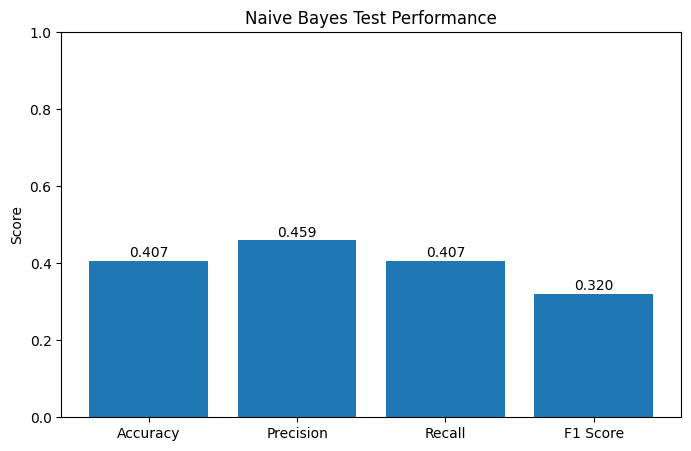

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

scores = [
    test_accuracy,
    test_precision,
    test_recall,
    test_f1
]

plt.figure(figsize=(8,5))

plt.bar(metrics, scores)

plt.ylim(0,1)

plt.title("Naive Bayes Test Performance")

plt.ylabel("Score")

for i, value in enumerate(scores):
    plt.text(i, value+0.01, f"{value:.3f}", ha="center")

plt.savefig(
    os.path.join(NB_PLOTS_DIR, "overall_metrics.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

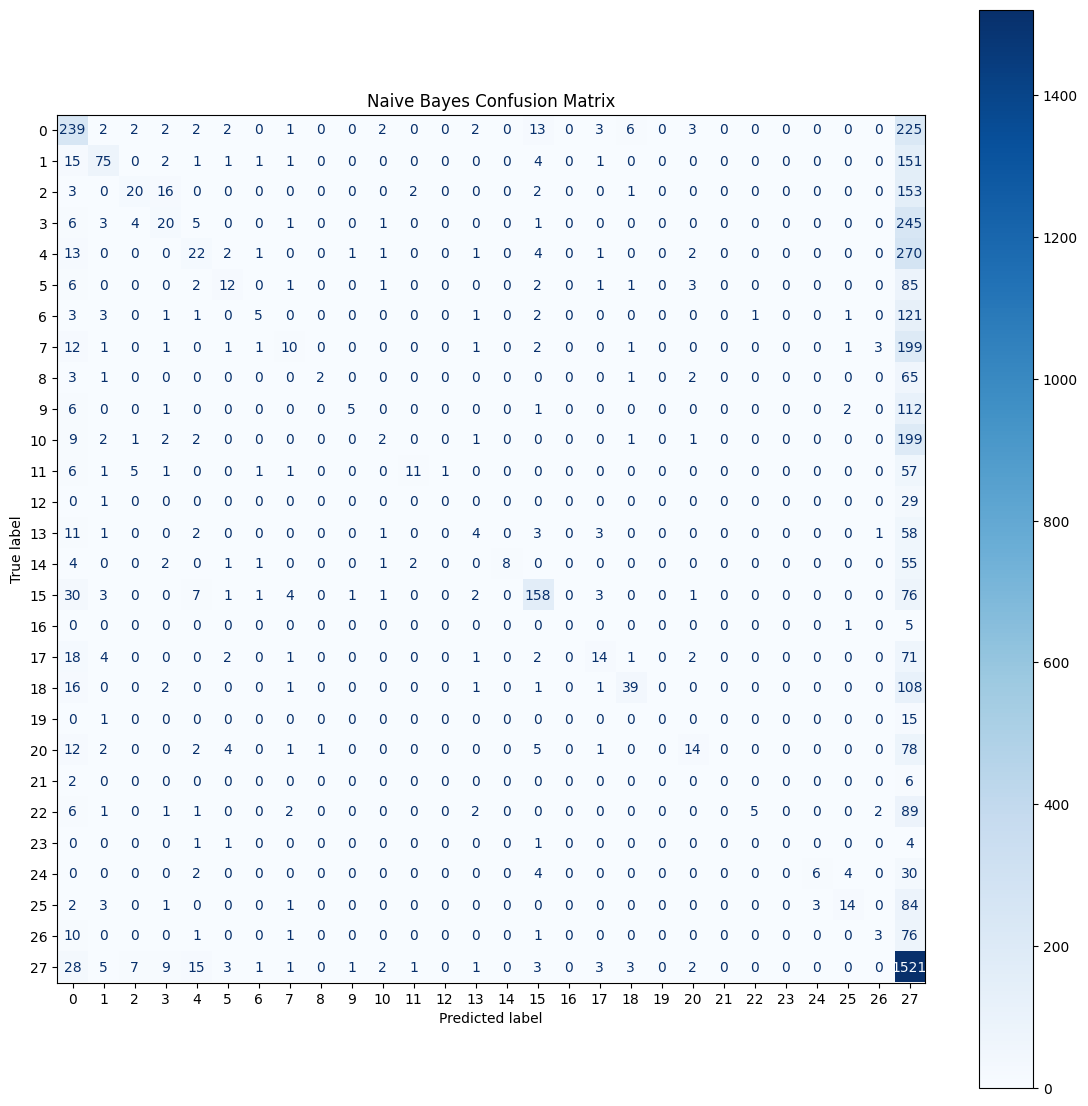

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm_test = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(14,14))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True,
    values_format="d"
)

plt.title("Naive Bayes Confusion Matrix")

plt.savefig(
    os.path.join(NB_PLOTS_DIR, "confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    zero_division=0
)

metrics_df = pd.DataFrame({
    "Class": range(len(precision)),
    "Precision": precision,
    "Recall": recall,
    "F1": f1
})

metrics_df.head()

,Class,Precision,Recall,F1
0,0,0.519565,0.474206,0.495851
1,1,0.688073,0.297619,0.415512
2,2,0.512821,0.101523,0.169492
3,3,0.327869,0.069930,0.115274
4,4,0.333333,0.069182,0.114583


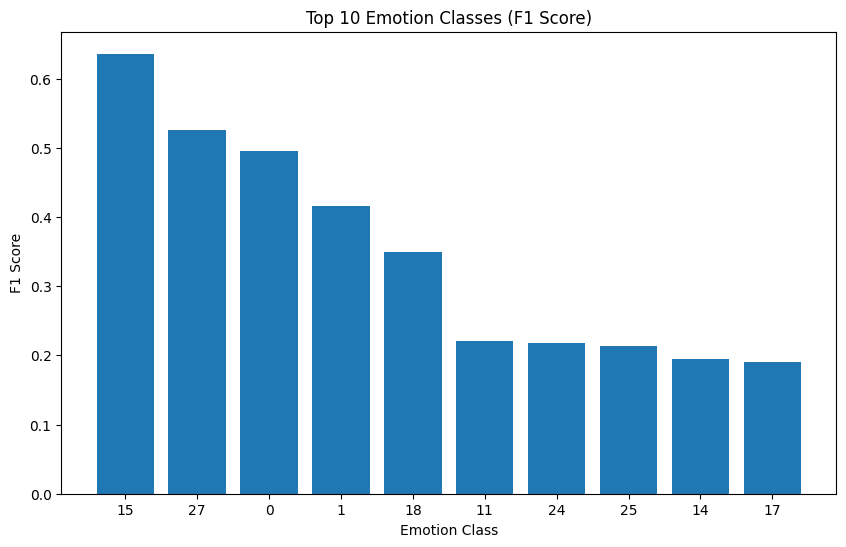

In [ ]:
top10 = metrics_df.sort_values(
    "F1",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10["Class"].astype(str),
    top10["F1"]
)

plt.title("Top 10 Emotion Classes (F1 Score)")

plt.xlabel("Emotion Class")

plt.ylabel("F1 Score")

plt.savefig(
    os.path.join(NB_PLOTS_DIR, "top10_classes.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

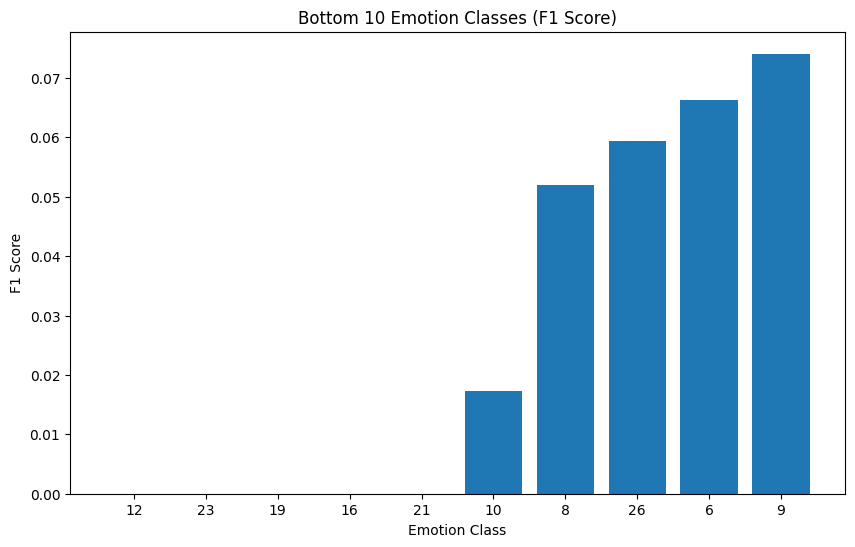

In [ ]:
bottom10 = metrics_df.sort_values(
    "F1",
    ascending=True
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    bottom10["Class"].astype(str),
    bottom10["F1"]
)

plt.title("Bottom 10 Emotion Classes (F1 Score)")

plt.xlabel("Emotion Class")

plt.ylabel("F1 Score")

plt.savefig(
    os.path.join(NB_PLOTS_DIR, "bottom10_classes.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

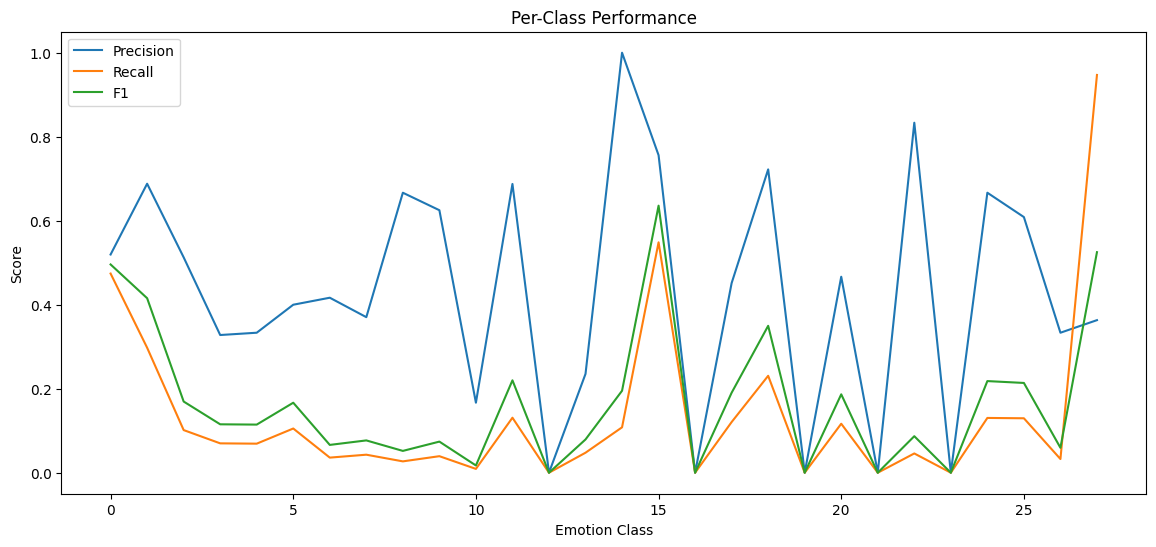

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(metrics_df["Class"], metrics_df["Precision"], label="Precision")
plt.plot(metrics_df["Class"], metrics_df["Recall"], label="Recall")
plt.plot(metrics_df["Class"], metrics_df["F1"], label="F1")

plt.xlabel("Emotion Class")

plt.ylabel("Score")

plt.title("Per-Class Performance")

plt.legend()

plt.savefig(
    os.path.join(NB_PLOTS_DIR, "per_class_metrics.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

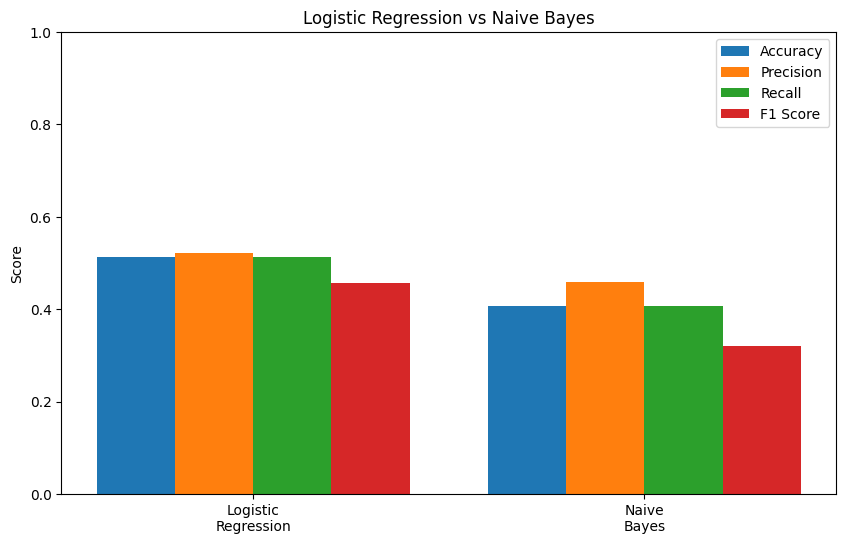

In [ ]:
#comparision with LR
import matplotlib.pyplot as plt
import numpy as np
import os

# Models
models = ["Logistic\nRegression", "Naive\nBayes"]

# Test Scores
accuracy = [0.5126, 0.4070]
precision = [0.5213, 0.4592]
recall = [0.5126, 0.4070]
f1 = [0.4562, 0.3203]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1, width, label="F1 Score")

plt.xticks(x, models)
plt.ylim(0,1)

plt.ylabel("Score")
plt.title("Logistic Regression vs Naive Bayes")

plt.legend()

plt.savefig(
    os.path.join(BASE_DIR, "plots", "Model_Comparison_LR_vs_NB.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from docx import Document
from docx.shared import Pt
import os

# Path to existing project document
project_doc = os.path.join(
    BASE_DIR,
    "Project_Documentation.docx"   # Change name if your file has a different name
)

# Open existing document
doc = Document(project_doc)

# ==========================================
# Add Progress Update
# ==========================================

doc.add_heading("Project Progress Update", level=1)

# ------------------------------------------
# Notebook 4
# ------------------------------------------

doc.add_heading("✅ Notebook 4: Logistic Regression (Completed)", level=2)

doc.add_paragraph(
    "Objective:\n"
    "Developed a Logistic Regression model for multi-class emotion "
    "classification using TF-IDF features extracted from the GoEmotions dataset."
)

doc.add_paragraph(
    "Work Completed:\n"
    "• Data loading and preprocessing\n"
    "• TF-IDF feature extraction (5000 features)\n"
    "• Model training\n"
    "• Validation and testing\n"
    "• Performance evaluation\n"
    "• Visualizations\n"
    "• Model and report generation"
)

doc.add_paragraph(
    "Final Test Results:\n"
    "Accuracy : 51.26%\n"
    "Precision: 52.13%\n"
    "Recall   : 51.26%\n"
    "F1 Score : 45.62%"
)

doc.add_paragraph(
    "Conclusion:\n"
    "Logistic Regression achieved the highest performance among the "
    "classical machine learning models evaluated so far."
)

# ------------------------------------------
# Notebook 5
# ------------------------------------------

doc.add_heading("✅ Notebook 5: Naive Bayes (Completed)", level=2)

doc.add_paragraph(
    "Objective:\n"
    "Implemented a Multinomial Naive Bayes classifier and optimized "
    "its smoothing parameter (alpha)."
)

doc.add_paragraph(
    "Work Completed:\n"
    "• Model training\n"
    "• Hyperparameter tuning (alpha = 0.1, 0.5, 1.0, 2.0)\n"
    "• Selected best alpha = 0.1\n"
    "• Validation and testing\n"
    "• Performance evaluation\n"
    "• Visualizations\n"
    "• Model and report generation"
)

doc.add_paragraph(
    "Final Test Results:\n"
    "Accuracy : 40.70%\n"
    "Precision: 45.92%\n"
    "Recall   : 40.70%\n"
    "F1 Score : 32.03%"
)

doc.add_paragraph(
    "Conclusion:\n"
    "Naive Bayes served as a fast baseline model. "
    "Although computationally efficient, it performed "
    "below Logistic Regression on the GoEmotions dataset."
)

# ------------------------------------------
# Upcoming Work
# ------------------------------------------

doc.add_heading("🚀 Upcoming Work", level=1)

doc.add_heading("Notebook 6: Random Forest", level=2)

doc.add_paragraph(
    "Planned Tasks:\n"
    "• Load cleaned GoEmotions dataset\n"
    "• Apply TF-IDF feature extraction\n"
    "• Train Random Forest classifier\n"
    "• Hyperparameter tuning\n"
    "• Validation and testing\n"
    "• Generate visualizations\n"
    "• Compare results with Logistic Regression and Naive Bayes\n"
    "• Save trained model\n"
    "• Generate experiment report"
)

doc.add_paragraph(
    "Expected Outcome:\n"
    "Evaluate whether the Random Forest ensemble model can improve "
    "emotion classification performance compared with the previously "
    "implemented classical machine learning models."
)

# ==========================================
# Save
# ==========================================

doc.save(project_doc)

print("✅ Project document updated successfully!")
print(project_doc)

✅ Project document updated successfully!
/content/drive/MyDrive/HumanBehaviourSimulator/Project_Documentation.docx
